In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [6]:
df = pd.read_csv(r"D:\Narendra\CSV Files\dirty_cafe_sales.csv")
df

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11
...,...,...,...,...,...,...,...,...
9995,TXN_7672686,Coffee,2,2.0,4.0,NaN,UNKNOWN,2023-08-30
9996,TXN_9659401,NaN,3,NaN,3.0,Digital Wallet,NaN,2023-06-02
9997,TXN_5255387,Coffee,4,2.0,8.0,Digital Wallet,NaN,2023-03-02
9998,TXN_7695629,Cookie,3,NaN,3.0,Digital Wallet,NaN,2023-12-02


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    10000 non-null  str  
 1   Item              9667 non-null   str  
 2   Quantity          9862 non-null   str  
 3   Price Per Unit    9821 non-null   str  
 4   Total Spent       9827 non-null   str  
 5   Payment Method    7421 non-null   str  
 6   Location          6735 non-null   str  
 7   Transaction Date  9841 non-null   str  
dtypes: str(8)
memory usage: 625.1 KB


In [7]:
df.shape

(10000, 8)

# Step 1

Check missing values

In [3]:
df.isnull().sum()

Transaction ID         0
Item                 333
Quantity             138
Price Per Unit       179
Total Spent          173
Payment Method      2579
Location            3265
Transaction Date     159
dtype: int64

# Step 2

Replace UNKNOWN and ERROR with NaN

In [5]:
df.replace(['UNKNOWN','ERROR'], np.nan, inplace=True)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,NaN,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,NaN,NaN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11
...,...,...,...,...,...,...,...,...
9995,TXN_7672686,Coffee,2,2.0,4.0,NaN,NaN,2023-08-30
9996,TXN_9659401,NaN,3,NaN,3.0,Digital Wallet,NaN,2023-06-02
9997,TXN_5255387,Coffee,4,2.0,8.0,Digital Wallet,NaN,2023-03-02
9998,TXN_7695629,Cookie,3,NaN,3.0,Digital Wallet,NaN,2023-12-02


# Step 3

Convert columns to correct datatype

In [9]:
df['Quantity'] = pd.to_numeric(df['Quantity'])
df['Price Per Unit'] = pd.to_numeric(df['Price Per Unit'])
df['Total Spent'] = pd.to_numeric(df['Total Spent'])

# Step 4

Fill missing values

In [7]:
df['Payment Method'].fillna(df['Payment Method'].mode()[0], inplace=True)

C:\Users\ocean\AppData\Local\Temp\ipykernel_19632\4276647020.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Payment Method'].fillna(df['Payment Method'].mode()[0], inplace=True)


0          Credit Card
1                 Cash
2          Credit Card
3              UNKNOWN
4       Digital Wallet
             ...      
9995    Digital Wallet
9996    Digital Wallet
9997    Digital Wallet
9998    Digital Wallet
9999              Cash
Name: Payment Method, Length: 10000, dtype: str

# Step 5

Verify

In [11]:
df.info()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    10000 non-null  str    
 1   Item              9031 non-null   str    
 2   Quantity          9521 non-null   float64
 3   Price Per Unit    9467 non-null   float64
 4   Total Spent       9498 non-null   float64
 5   Payment Method    6822 non-null   str    
 6   Location          6039 non-null   str    
 7   Transaction Date  9540 non-null   str    
dtypes: float64(3), str(5)
memory usage: 625.1 KB


Transaction ID         0
Item                 969
Quantity             479
Price Per Unit       533
Total Spent          502
Payment Method      3178
Location            3961
Transaction Date     460
dtype: int64

# Chart 1: Most Sold Products
Bar Chart

<Axes: xlabel='Item'>

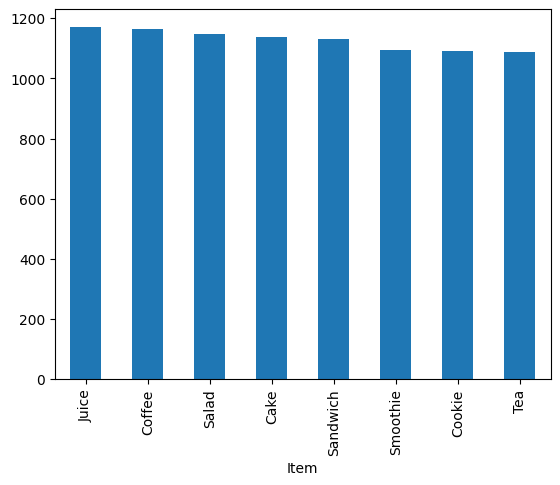

In [12]:
df['Item'].value_counts().plot(kind='bar')

Shows:

Which item is sold most
Which item is sold least

# Chart 2: Payment Method Usage
Pie Chart

<Axes: >

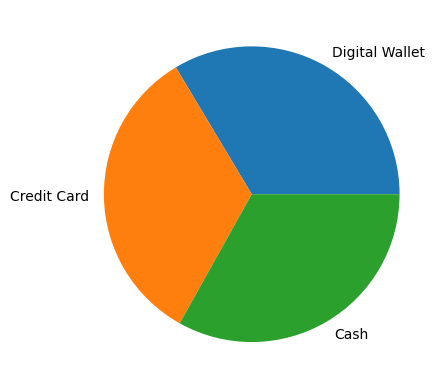

In [14]:
df['Payment Method'].value_counts().plot(kind='pie')

In [ ]:
Shows:

Cash %
Credit Card %
Digital Wallet %

# Chart 3: In-store vs Takeaway
Pie Chart

<Axes: >

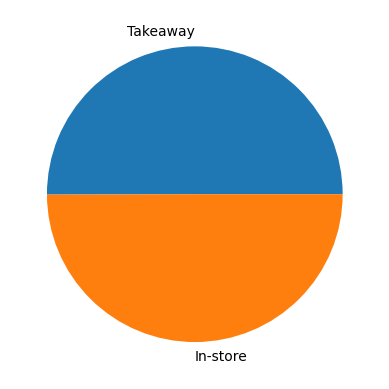

In [15]:
df['Location'].value_counts().plot(kind='pie')

Shows customer preference.

# Chart 4: Revenue by Product
Bar Chart

<Axes: ylabel='Item'>

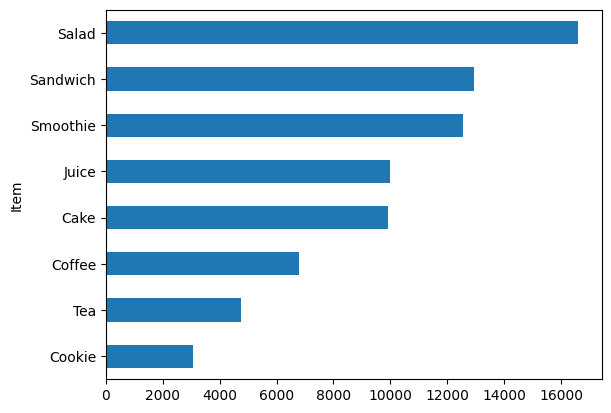

In [19]:
df.groupby('Item')['Total Spent'].sum().sort_values().plot(kind='barh')

Shows:

Which item earns the most money.

# Chart 5: Sales Trend Over Time
Line Chart

<Axes: xlabel='Transaction Date'>

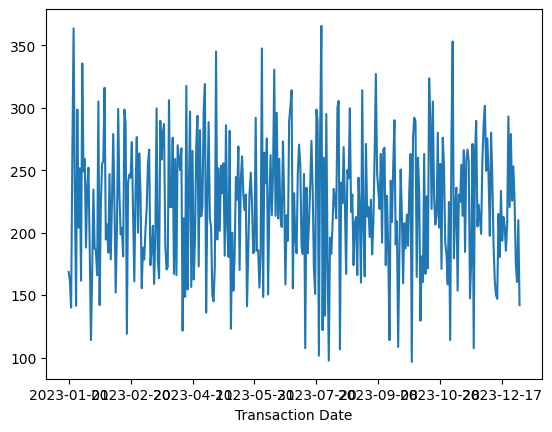

In [20]:
daily_sales = df.groupby('Transaction Date')['Total Spent'].sum()
daily_sales.plot()

Shows:

Increasing sales
Decreasing sales

# Chart 6: Quantity Distribution
Histogram

<Axes: >

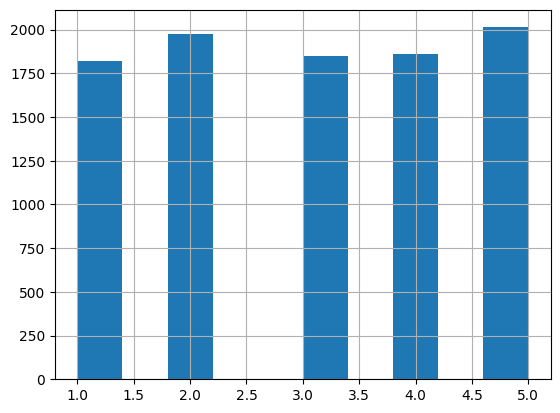

In [21]:
df['Quantity'].hist()

Shows:

Most customers buy 1 item?
2 items?
5 items?

# Insights

Insight 1

Coffee, Juice, Salad, and Cake appear among the most frequently purchased products.

Business Meaning:

These are the café's most popular products.

Insight 2

A large number of missing values exist in Payment Method and Location.

Business Meaning:

Data entry process needs improvement.

Insight 3

Digital Wallet, Cash, and Credit Card are the main payment methods.

Business Meaning:

Customers prefer multiple payment options.

Insight 4

Takeaway and In-store sales are almost similar.

Business Meaning:

Both service types are important for business.

Insight 5

Some rows contain ERROR and UNKNOWN values.

Business Meaning:

Data quality issues exist and must be fixed before reporting.

# Conclusion:

I worked on a Café Sales dataset containing 10,000 transactions. First, I identified missing values, UNKNOWN values, and ERROR values. Then I cleaned the dataset by replacing invalid values and converting columns to proper datatypes. After cleaning, I performed exploratory data analysis using bar charts, pie charts, histograms, and line charts. I analyzed product popularity, payment methods, customer purchase locations, and revenue trends. The analysis showed the most popular products, customer payment preferences, and several data-quality issues that should be addressed for better reporting.